In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
    
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from matplotlib.colors import ListedColormap, TwoSlopeNorm
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter, LatitudeLocator
import cartopy.feature as cfeature
from numpy import meshgrid
from typing import List
import config.dataUtils as dutils
import config.plotUtils as putils
import config.metricUtils as mutils
import config.fdUtils as fdutils
import bottleneck as bn
import os
from scipy.stats import percentileofscore as pos
from multiprocessing import Pool
import config.fdUtils_2 as fdutils_2
from geopy.geocoders import Nominatim
from opencage.geocoder import OpenCageGeocode
import config.FDtimeSeriesPlot as fdplot
import config.FDtsPlotRealtime as fdREAL
import config.STATIC as call


for pet_or_refet in ['pet','refet']:
    fdREAL.run_FD_time_series_plots_REALTIME(all_dates_or_doy=call.all_dates_or_doy, pet_or_refet=pet_or_refet,year_ranges_tuple=call.long_clim, window=call.window)

Plotting grid cell number 0 out of 4.
Working on index lat Y 28 and X 46 for state/region Kansas.
Working on index time values (62, 66).
Completed all of the FD events for a particular grid cell
Plotting grid cell number 1 out of 4.
Working on index lat Y 11 and X 80 for state/region Florida.
Completed all of the FD events for a particular grid cell
Plotting grid cell number 2 out of 4.
Working on index lat Y 28 and X 98 for state/region Maryland.
Working on index time values (176, 179).
Completed all of the FD events for a particular grid cell
Plotting grid cell number 3 out of 4.
Working on index lat Y 23 and X 66 for state/region Arkansas.
Completed all of the FD events for a particular grid cell
Plotting grid cell number 0 out of 4.
Working on index lat Y 28 and X 46 for state/region Kansas.
Working on index time values (62, 66).
Completed all of the FD events for a particular grid cell
Plotting grid cell number 1 out of 4.
Working on index lat Y 11 and X 80 for state/region Florid

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [3]:
window=0
year_ranges_tuple = (1981,2020)
all_dates_or_doy = 'by_doy'
pet_or_refet = 'pet'

# Select a single file

In [ ]:
# (lat, lon)
# (40,30) = in between Wyoming and Montana border
# (35,60) = on the left part of Iowa state (but no 2012 FD - so let's move south a little bit and more east)
# (32,70) = Northwest Illinois
# (20,20) = California near the Mojave desert
# (24,31) = Northeast Arizona, inside of Tribal Land
# (16,90) = Southeast South Carolina (near the coasts)
# (16,80) = Center of Georgia/Alabama line (in the middle of both states)
# (31,76) = Middle Indiana - good for 2012 flash drought

Working on index lat Y 31 and X 76 for state/region Indiana.
Working on index time values (9, 12).
Cannot make this plot for USDM because it is before the year 2000
Working on index time values (67, 70).


KeyboardInterrupt: 

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

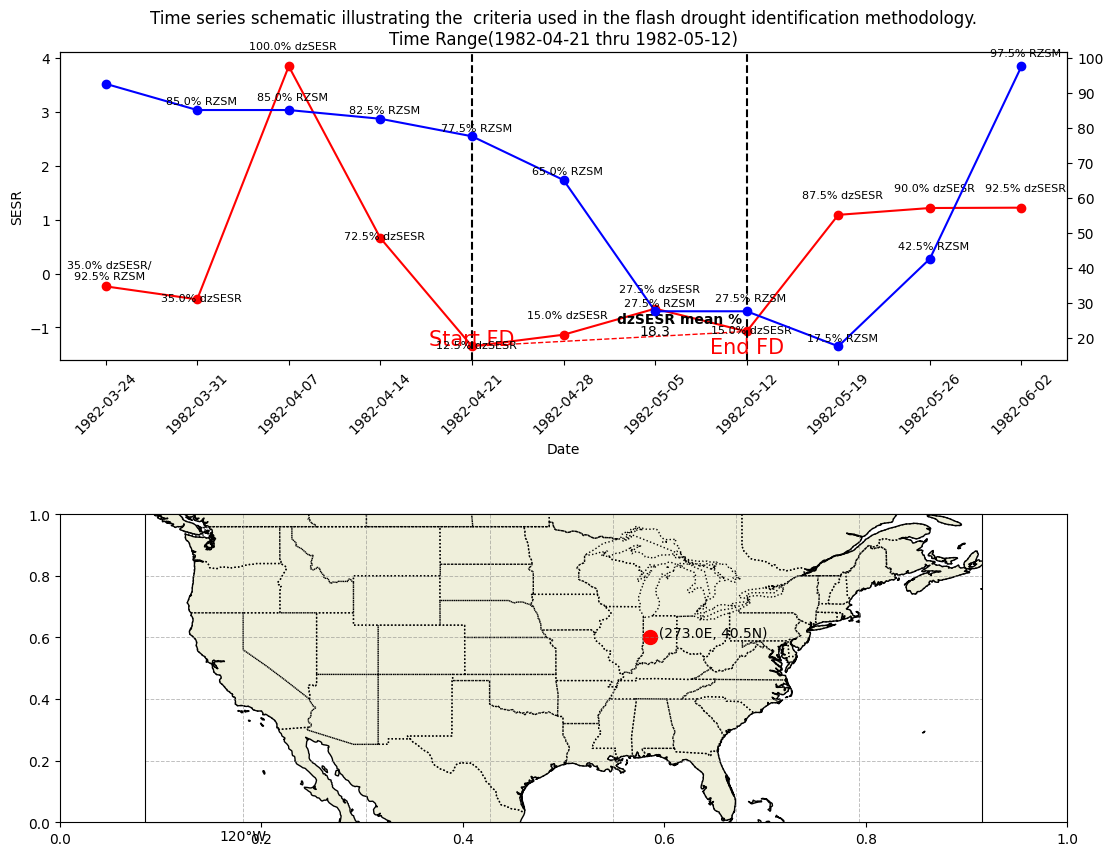

In [110]:
for all_dates_or_doy in ['by_doy']:
    for pet_or_refet in ['pet','refet']:
        fdplot.run_FD_time_series_plots(all_dates_or_doy, pet_or_refet,year_ranges_tuple=(1981,2020), window=0)

In [ ]:
# (lat, lon)
# (28,46) = northern high plains (for 2024)
# (11,80) = Southeast US (for 2024)
# (28,98) = Northeast US (for 2024)


In [111]:

for pet_or_refet in ['pet','refet']:
    fdREAL.run_FD_time_series_plots_REALTIME(all_dates_or_doy=call.all_dates_or_doy, pet_or_refet=pet_or_refet,year_ranges_tuple=call.long_clim, window=call.window)

Working on index lat Y 28 and X 46 for state/region Kansas.
Working on index time values (62, 66).


KeyError: "No variable named 'fd_2'. Variables on the dataset include ['time', 'lon', 'lat', 'fd_start']"

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

# Make plots

In [ ]:
# Define the months to be masked (December, January, February)
winter_months = [12, 1, 2]

# Create a mask: True for the months to be masked, False otherwise
mask = fd['time.month'].isin(winter_months)

# Apply the mask to set values to 0 for the specified months, 1 otherwise
file_masked = xr.where(~mask, fd['fd_pet_s3'],0)

In [ ]:
file_masked

In [ ]:
file_masked.sel(time='2012-07-20',method='nearest').plot()

In [ ]:
ds_annual_sum = file_masked.resample(time='A').sum()

ds_annual_sum_mask  = xr.where(ds_annual_sum >=1,1,0)

ds_annual_sum_mask.mean(dim='time').plot()

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# # Example data
# time_points = np.array([1, 6, 11, 16, 21, 26, 31, 36, 41, 46, 51, 56, 61])
# sesr_values = np.array([0.5, 0.3, 0.2, 0, -0.5, -1, -1.5, -2, -2.5, -3, -2.7, -3, -2.8])
# rapid_intensification_start = 26
# rapid_intensification_end = 56
# markers = [26, 56]  # Example markers for P4, P6, etc.

# plt.figure(figsize=(10, 6))

# # Plot SESR values
# plt.plot(time_points, sesr_values, 'o-', color='red', label='Mean ΔSESR')
# plt.axvline(x=rapid_intensification_start, color='black', linestyle='--')
# plt.axvline(x=rapid_intensification_end, color='black', linestyle='--')

# # Annotations
# for i, txt in enumerate(time_points):
#     plt.annotate(f'{txt}th', (time_points[i], sesr_values[i]), textcoords="offset points", xytext=(0, 10), ha='center')

# # Highlight markers
# for marker in markers:
#     plt.plot(marker, sesr_values[time_points == marker], 'o', color='black')
#     plt.annotate(f'P{markers.index(marker) + 4}', (marker, sesr_values[time_points == marker]), textcoords="offset points", xytext=(10, -10), ha='center')

# # Labels and title
# plt.xlabel('Pentad')
# plt.ylabel('SESR')
# plt.title('A time series schematic illustrating the four criteria used in the flash drought identification methodology')
# plt.legend()

# # Custom text
# plt.text(15, -0.25, 'Rapid Drought Intensification Begins', rotation=90, verticalalignment='center')
# plt.text(45, -0.25, 'Rapid Drought Intensification Ends', rotation=90, verticalalignment='center')
# plt.text(30, -3.2, 'Flash Drought Length: 6 SESR Changes (7 Total Pentads)', horizontalalignment='center')

# plt.show()
